In [45]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [46]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors

In [47]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [48]:
rot = False
u = 10

#dycore = 'fv3'
dycore = 'se'
#dycore = 'fv'

#res = 'ne30'
res = 'ne60'

lev_no = 'ztop20km_L56'

#extra_name1 = 'no_rf'
extra_name1 = 'tau_1_4'
extra_name2 = 'tau_1_8'
extra_name3 = 'tau_1_16'
extra_name4 = 'tau_1_20'

CAM_branch = 'CAM_6_4_100_11082025'

test_name_start = 'cam_6_4_100'

case = f'{test_name_start}_{dycore}_{res}_{lev_no}'


# Compare three files
if rot:
    nc_file1 = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name1}'
    nc_file2 = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name2}'
    nc_file3 = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name3}'
    nc_file4 = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name4}'
else:
    nc_file1 = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name1}'
    nc_file2 = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name2}'
    nc_file3 = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name3}'
    nc_file4 = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name4}'

if dycore ==  'fv3':
    nc_file1 = f'{nc_file1}.regrid.1x1'

nc_file1 = nc_file1 + '.nc'
nc_file2 = nc_file2 + '.nc'
nc_file3 = nc_file3 + '.nc'
nc_file4 = nc_file4 + '.nc'

In [49]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case + '/run/' + nc_file1
run_path2 = run_base + case + '/run/' + nc_file2
run_path3 = run_base + case + '/run/' + nc_file3
run_path4 = run_base + case + '/run/' + nc_file4

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)
nc3 = Dataset(run_path3)
nc4 = Dataset(run_path4)

In [50]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 
lev = nc1['lev'][:]

In [51]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat
lat_crop_up = 50.
lat_cent_down = -50.

lat_ticks = np.linspace(-40,40,5)

lon_crop_left = 60.

if rot == True:
    lon_crop_right = 170.
    lon_ticks = np.linspace(80, 160, 5)
else:
    lon_crop_right = 150.
    lon_ticks = np.linspace(80, 140, 4)

lon_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))[0]
lat_inds = np.where((lat < lat_crop_up) & (lat > lat_cent_down))[0]

lat = lat[lat_inds]
lon = lon[lon_inds]

LON, LAT = np.meshgrid(lon, lat)

In [52]:
# Field to compare
field = 'T'

# Time index to compare at
t_idx = 40

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

# Choice of colormap
# Choice of colormap
if field == 'T':        
    cmap_choice = 'jet'
else:
    cmap_choice = 'seismic'

In [53]:
# Interpolations:
field_vals1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals4 = z_interp(nc4['Z3'][t_idx, :, lat_inds, lon_inds], nc4[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)

In [54]:
deg2rad = np.pi/180
T0 = 288

if field == 'U':
    # Normalised velocity perturbation:
        field_vals1 = (field_vals1 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals2 = (field_vals2 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals3 = (field_vals3 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals4 = (field_vals4 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
else:
    # Temperature perturbation:
        field_vals1 = field_vals1 - T0
        field_vals2 = field_vals2 - T0
        field_vals3 = field_vals3 - T0
        field_vals4 = field_vals4 - T0

min value is -1.7049145966111041
max value is 7.491011548333404


Text(0.5, 0.01, 'Longitude (deg)')

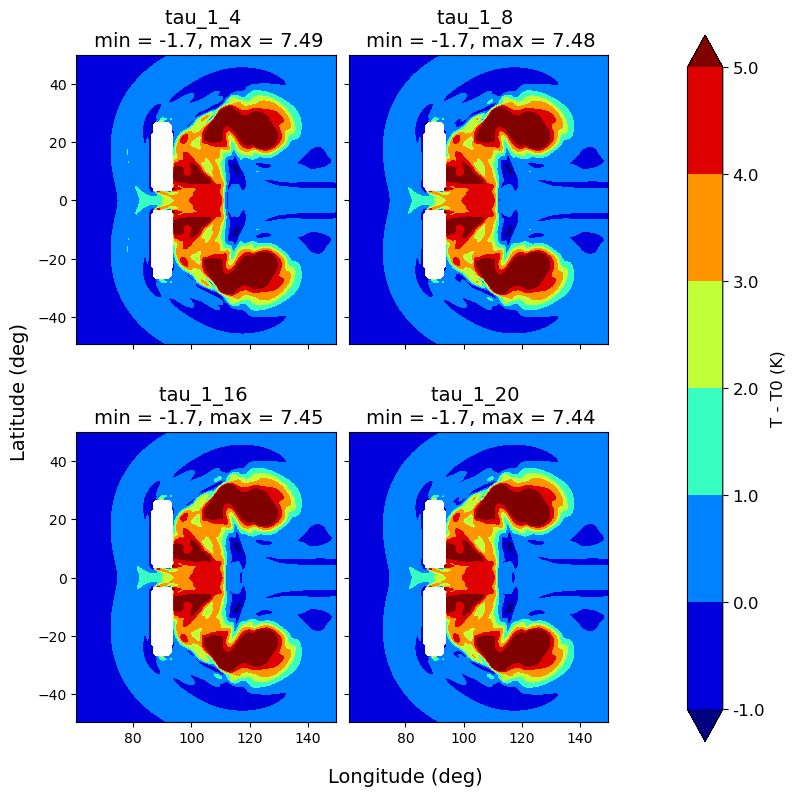

In [55]:
title_size=16
label_size=14
small_size=12

max1 = np.nanmax(field_vals1)
max2 = np.nanmax(field_vals2)
max3 = np.nanmax(field_vals3)
max4 = np.nanmax(field_vals4)

min1 = np.nanmin(field_vals1)
min2 = np.nanmin(field_vals2)
min3 = np.nanmin(field_vals3)
min4 = np.nanmin(field_vals4)

maxmax = max(max1, max2, max3, max4)
minmin = min(min1, min2, min3, min4)

print('min value is', minmin)
print('max value is', maxmax)

conts = np.linspace(minmin, maxmax, 21)

fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8,8), layout="constrained")
(ax1, ax2), (ax3, ax4) = axes

if field == 'T':
    if rot:
        conts = np.linspace(-1, 5, 7)
        norm = colors.Normalize(vmin=-1, vmax=5)
        tick_range = np.linspace(-1, 5, 7)
    else:
        conts = np.linspace(-1, 5, 7)
        norm = colors.Normalize(vmin=-1, vmax=5)
        tick_range = np.linspace(-1, 5, 7)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot4 = ax4.contourf(LON, LAT, field_vals4, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Temperature perturbation'
    cb_label = 'T - T0 (K)'
else:
    if rot:
        conts = np.linspace(-2.0, 2.0, 9)
        tick_range = np.linspace(-2.0, 2.0, 9)
        norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
    else:
        conts = np.linspace(-1.5, 1.0, 11)
        tick_range = np.linspace(-1.5, 1.0, 6)
        norm = colors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.0)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot4 = ax4.contourf(LON, LAT, field_vals4, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Normalised velocity perturbation'
    cb_label = '$(u(t) - u_0)/u_0$'

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')

cb = plt.colorbar(plot4,ax=axes,pad=0.15,shrink=1,format='%.1f')
cb.set_label(label=cb_label, size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{extra_name1} \n min = {np.round(min1,2)}, max = {np.round(max1,2)}', size=label_size)
ax2.set_title(f'{extra_name2} \n min = {np.round(min2,2)}, max = {np.round(max2,2)}', size=label_size)
ax3.set_title(f'{extra_name3} \n min = {np.round(min3,2)}, max = {np.round(max3,2)}', size=label_size)
ax4.set_title(f'{extra_name4} \n min = {np.round(min4,2)}, max = {np.round(max4,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

In [56]:
# Plot vertical cross sections to examine the damping/reflection of the gravity waves.
lon = nc1['lon'][:] 
lat = nc1['lat'][:] 
lon_crop_left = 50
lon_crop_right = 150

# User parameters:
t_idx = -1
field = 'W'

lon_ticks = np.linspace(lon_crop_left, lon_crop_right, 5)

lon_crop_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))
lon_crop = lon[lon_crop_inds]

LONGC, P = np.meshgrid(lon_crop, lev) 

# Pick the latitude to slice at:
#lat_val = 95  # 1 degree
lat_val = 200  # 0.5-degree

lat_val_deg = np.round(lat[lat_val],0)
print('lat in deg is', lat_val_deg)


if field=='W':
    Rd = 287.04
    g = 9.80616
    # Convert P from hPa to Pa
    P_Pa = P*100
    field1 = (Rd/g)*nc1['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc1['T'][t_idx, :, lat_val, lon_crop_inds[0]]/P_Pa
    field2 = (Rd/g)*nc2['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc2['T'][t_idx, :, lat_val, lon_crop_inds[0]]/P_Pa
    field3 = (Rd/g)*nc3['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc3['T'][t_idx, :, lat_val, lon_crop_inds[0]]/P_Pa
    field4 = (Rd/g)*nc4['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc4['T'][t_idx, :, lat_val, lon_crop_inds[0]]/P_Pa
else:
    field1 = nc1[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field2 = nc2[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field3 = nc3[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field4 = nc4[field][t_idx, :, lat_val, lon_crop_inds[0]]

ps_t = nc1['PS'][t_idx, lat_val, lon_crop_inds[0]]/100

cmap_choice = 'coolwarm'

lat in deg is 10.0


min value is -1.0014481544367002
max value is 2.649542760484456


Text(0.5, 0.98, 'W at t=0.5 days')

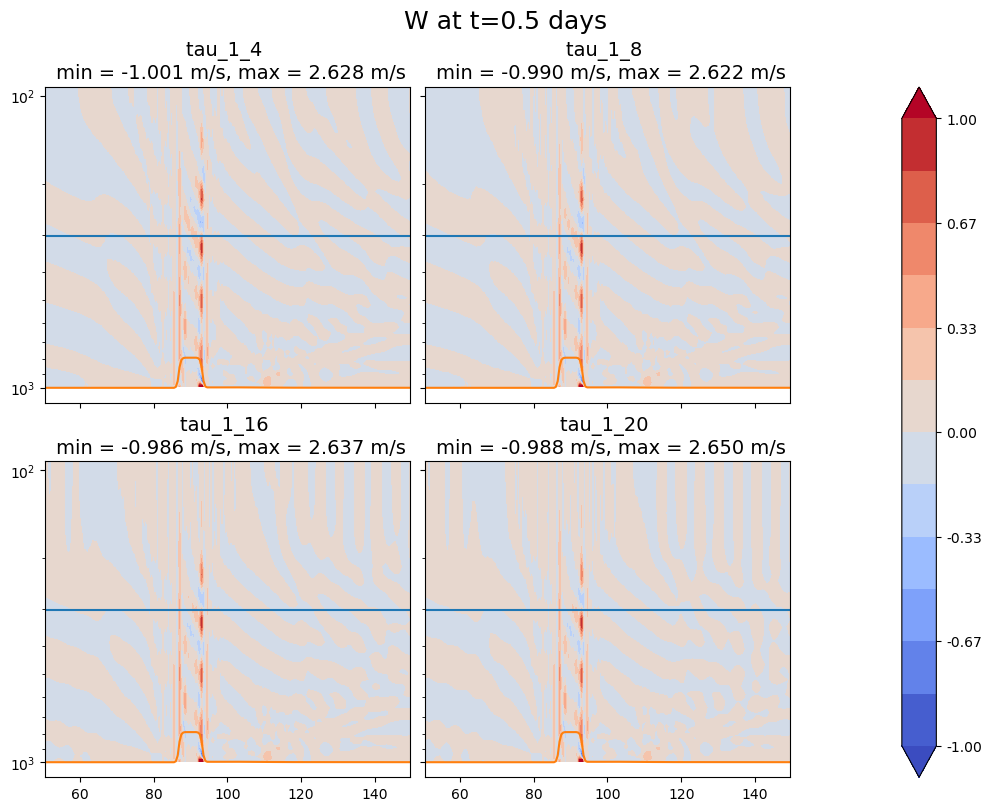

In [60]:

max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)
max4 = np.nanmax(field4)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)
min4 = np.nanmin(field4)

maxmax = max(max1, max2, max3, max4)
minmin = min(min1, min2, min3, min4)

print('min value is', minmin)
print('max value is', maxmax)

conts = np.linspace(minmin, maxmax, 21)

fig, axes = plt.subplots(2,2,figsize = (10,8), sharey=True, sharex=True, constrained_layout=True)
(ax1, ax2), (ax3, ax4) = axes

if field == 'T':
    minmin = -1
    maxmax = 1
    absmax = max(abs(minmin), abs(maxmax))
    norm = colors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
    conts = np.linspace(minmin, maxmax,13)
    tick_range = np.linspace(minmin, maxmax,13)
    plot1 = ax1.contourf(LONGC, P, field1, levels = conts, cmap=cmap_choice)
    plot2 = ax2.contourf(LONGC, P, field2, levels = conts, cmap=cmap_choice)
    plot3 = ax3.contourf(LONGC, P, field3, levels = conts, cmap=cmap_choice)
    plot4 = ax4.contourf(LONGC, P, field4, levels = conts, cmap=cmap_choice)

    title = 'Temperature perturbation'
    cb_label = 'T - T0 (K)'
    unit = 'K'
if field == 'OMEGA':
    minmin = -1
    maxmax = 1
    absmax = max(abs(minmin), abs(maxmax))
    norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
    conts = np.linspace(minmin, maxmax, 13)
    tick_range = np.linspace(minmin, maxmax, 5)
    plot1 = ax1.contourf(LONGC, P, field1, levels = conts, cmap=cmap_choice)
    plot2 = ax2.contourf(LONGC, P, field2, levels = conts, cmap=cmap_choice)
    plot3 = ax3.contourf(LONGC, P, field3, levels = conts, cmap=cmap_choice)
    plot4 = ax4.contourf(LONGC, P, field4, levels = conts, cmap=cmap_choice)
    title = 'OMEGA'
    cb_label = 'Pa/s'
    unit = 'Pa/s'
if field == 'W':
    minmin = -1
    maxmax = 1
    absmax = max(abs(minmin), abs(maxmax))
    norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
    conts = np.linspace(minmin, maxmax, 13)
    tick_range = np.linspace(minmin, maxmax, 5)
    plot1 = ax1.contourf(LONGC, P, field1, levels = conts, cmap=cmap_choice, extend='both')
    plot2 = ax2.contourf(LONGC, P, field2, levels = conts, cmap=cmap_choice, extend='both')
    plot3 = ax3.contourf(LONGC, P, field3, levels = conts, cmap=cmap_choice, extend='both')
    plot4 = ax4.contourf(LONGC, P, field4, levels = conts, cmap=cmap_choice, extend='both')
    title = 'W'
    cb_label = 'm/s'
    unit = 'm/s'
else:
    if minmin < 0:
        norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
    else:
        norm = colors.TwoSlopeNorm(vmin=-maxmax, vcenter=0, vmax=maxmax)
    plot1 = ax1.contourf(LONGC1, P1, field1, levels = conts, cmap=cmap_choice, norm=norm)
    plot2 = ax2.contourf(LONGC1, P1, field2, levels = conts, cmap=cmap_choice, norm=norm)
    plot3 = ax3.contourf(LONGC1, P1, field3, levels = conts, cmap=cmap_choice, norm=norm)

cb = plt.colorbar(plot4,ax=axes,pad=0.15,shrink=1,format='%.2f')

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')
ax4.set_yscale('log')

ax1.invert_yaxis()

# Plot the sponge layer start:
pc = 301.82

ax1.plot(lon_crop, pc*np.ones_like(lon_crop))
ax2.plot(lon_crop, pc*np.ones_like(lon_crop))
ax3.plot(lon_crop, pc*np.ones_like(lon_crop))
ax4.plot(lon_crop, pc*np.ones_like(lon_crop))

# Add the surface topography:
ax1.plot(lon_crop, ps_t)
ax2.plot(lon_crop, ps_t)
ax3.plot(lon_crop, ps_t)
ax4.plot(lon_crop, ps_t)

ax1.set_title(f'{extra_name1} \n min = {min1:.3f} m/s, max = {max1:.3f} m/s', size=label_size)
ax2.set_title(f'{extra_name2} \n min = {min2:.3f} m/s, max = {max2:.3f} m/s', size=label_size)
ax3.set_title(f'{extra_name3} \n min = {min3:.3f} m/s, max = {max3:.3f} m/s', size=label_size)
ax4.set_title(f'{extra_name4} \n min = {min4:.3f} m/s, max = {max4:.3f} m/s', size=label_size)

plt.suptitle(f'{field} at t={time[t_idx]} days',size=18)

Text(0.5, 1.0, 'τ = 1/4 days \n \n min = -0.988 m/s \n max = 2.650 m/s')

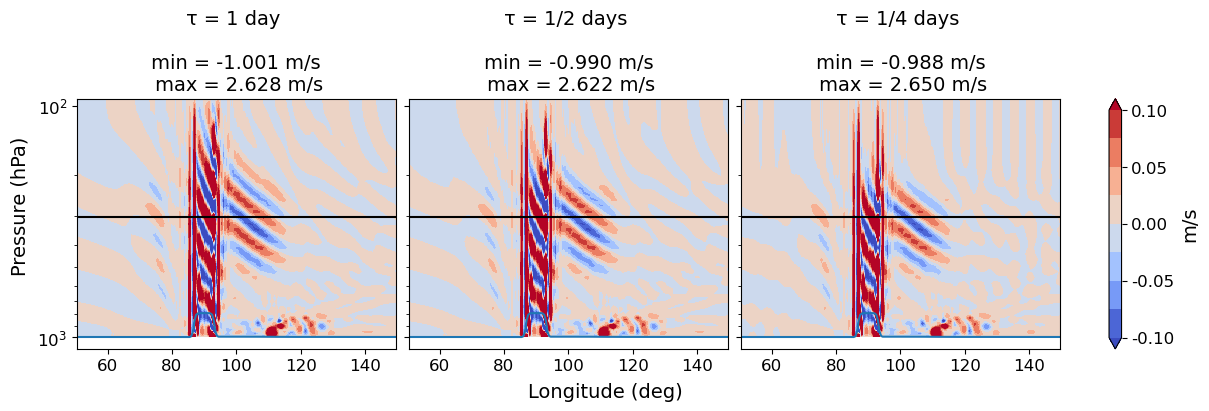

In [58]:
# Make a three by three plot. For putting in the paper.
# comparing no RF, chosen tau, and tau too large

max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)

fig, axes = plt.subplots(1,3,figsize = (12,4), sharey=True, constrained_layout=True)
(ax1, ax2, ax3) = axes

minmin = -0.1
maxmax = 0.1
absmax = max(abs(minmin), abs(maxmax))
norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
conts = np.linspace(minmin, maxmax, 9)
tick_range = np.linspace(minmin, maxmax, 5)
plot1 = ax1.contourf(LONGC, P, field1, levels = conts, cmap=cmap_choice, extend='both')
plot2 = ax2.contourf(LONGC, P, field2, levels = conts, cmap=cmap_choice, extend='both')
plot3 = ax3.contourf(LONGC, P, field4, levels = conts, cmap=cmap_choice, extend='both')
title = 'W'
cb_label = 'm/s'
unit = 'm/s'

cb = plt.colorbar(plot3,ax=axes,pad=0.05,shrink=1,format='%.2f', ticks = tick_range)
cb.ax.tick_params(labelsize=12)
cb.set_label('m/s', size=14)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

fig.supylabel('Pressure (hPa)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

ax1.invert_yaxis()

# Plot the sponge layer start:
pc = 301.82

ax1.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax3.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')

# Add the surface topography:
ax1.plot(lon_crop, ps_t)
ax2.plot(lon_crop, ps_t)
ax3.plot(lon_crop, ps_t)

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax3.tick_params(axis='both', which='major', labelsize=12)

#ax1.set_title(f'No Rayleigh friction \n \n min = {min1:.3f} m/s \n max = {max1:.3f} m/s', size=label_size)
ax1.set_title(f'\u03C4 = 1 day \n \n min = {min1:.3f} m/s \n max = {max1:.3f} m/s', size=label_size)
ax2.set_title(f'\u03C4 = 1/2 days \n \n min = {min2:.3f} m/s \n max = {max2:.3f} m/s', size=label_size)
ax3.set_title(f'\u03C4 = 1/4 days \n \n min = {min4:.3f} m/s \n max = {max4:.3f} m/s', size=label_size)
